Codveda Technologies
Level 1 Task 2: Exploratory Data Analysis
(EDA)

Load , import and inspect your data 

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
Stock_prices = pd.read_csv(r"c:\Users\User\Documents\Stock Prices Data Set.csv")

In [26]:
Stock_prices.head()

,symbol,date,open,high,low,close,volume
0,AAL,2/01/2014,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2/01/2014,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2/01/2014,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2/01/2014,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2/01/2014,70.1100,70.2300,69.4800,69.8900,1148391


Date column recognition with pandas

In [27]:
Stock_prices['date'] = pd.to_datetime(Stock_prices['date'],format='%d/%m/%Y')

In [28]:
Stock_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  object        
 1   date    497472 non-null  datetime64[ns]
 2   open    497461 non-null  float64       
 3   high    497464 non-null  float64       
 4   low     497464 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 26.6+ MB


In [29]:
Stock_prices.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

Replacing missing value with 0

In [30]:
Stock_prices = Stock_prices.fillna({'open': 0, 'high': 0, 'low': 0})

In [31]:
Stock_prices.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [32]:
Stock_prices[['open','high','low','close','volume']].describe()

,open,high,low,close,volume
count,497472.000000,497472.000000,497472.000000,497472.000000,4.974720e+05
mean,86.350365,87.131161,85.551092,86.369082,4.253611e+06
std,101.470918,102.311836,100.570734,101.472407,8.232139e+06
min,0.000000,0.000000,0.000000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.350000,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


Finding the statistics for the numerical columns mean, median, mode and std 
from our tasks objectives

In [33]:
Stock_prices[['open','high','low','close','volume']].mean()

open      8.635037e+01
high      8.713116e+01
low       8.555109e+01
close     8.636908e+01
volume    4.253611e+06
dtype: float64

In [34]:
Stock_prices[['open','high','low','close','volume']].median()

open           64.97
high           65.56
low            64.35
close          64.98
volume    2084896.50
dtype: float64

In [35]:
Stock_prices[['open','high','low','close','volume']].mode().iloc[0]

open           70.0
high           72.0
low            77.0
close          34.5
volume    1241019.0
Name: 0, dtype: float64

In [36]:
Stock_prices[['open','high','low','close','volume']].std()

open      1.014709e+02
high      1.023118e+02
low       1.005707e+02
close     1.014724e+02
volume    8.232139e+06
dtype: float64

Histogram for stock prices and trading volume.

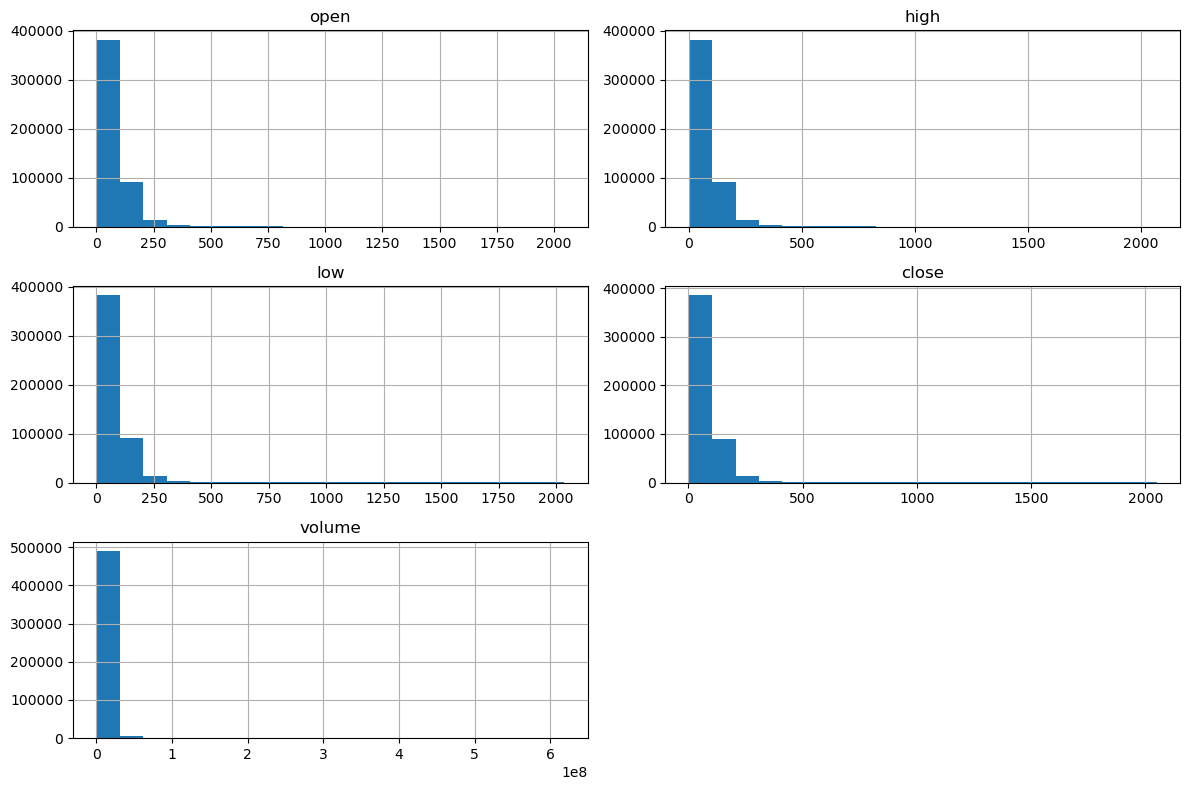

In [37]:
import matplotlib.pyplot as plt
Stock_prices[['open','high','low','close','volume']].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

Boxplots for price and volume 

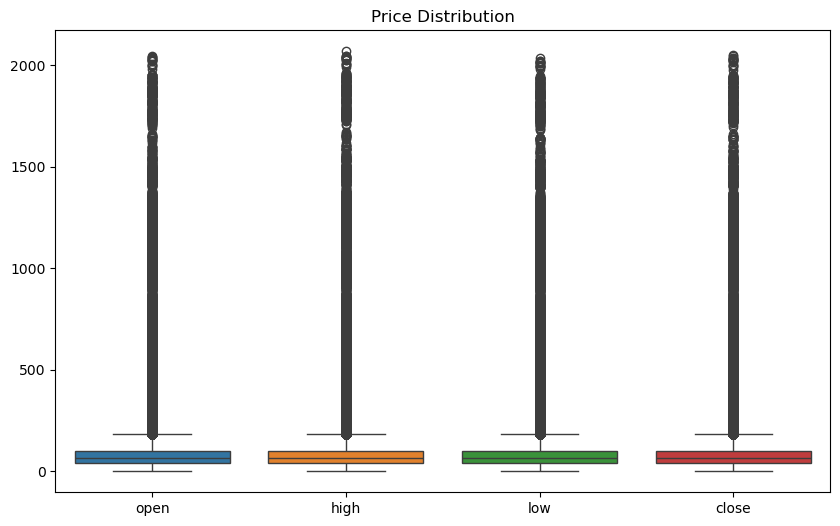

In [38]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=Stock_prices[['open','high','low','close']])
plt.title("Price Distribution")
plt.show()

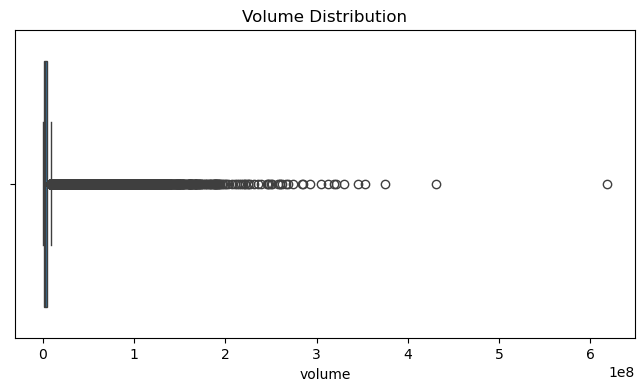

In [39]:
plt.figure(figsize=(8,4))
sns.boxplot(x=Stock_prices['volume'])
plt.title("Volume Distribution")
plt.show()

Scatter plots for open vs close price and volume vs close price 

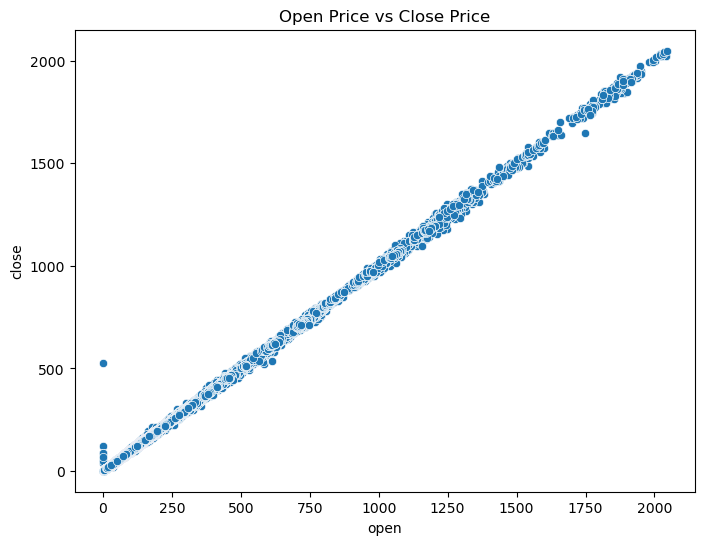

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='open',y='close',data=Stock_prices)
plt.title('Open Price vs Close Price')
plt.show()

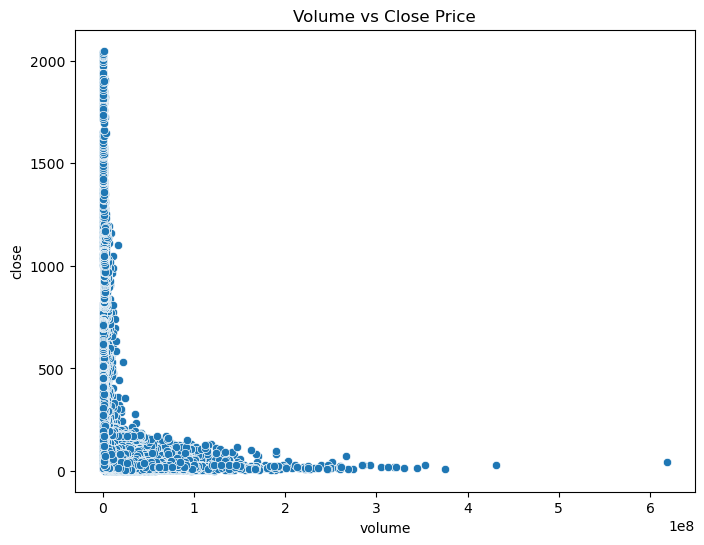

In [41]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='volume',y='close',data=Stock_prices)
plt.title('Volume vs Close Price')
plt.show()

Correlation Analysis, heatmap

In [42]:
corr = Stock_prices[['open','high','low','close','volume']].corr()
print(corr)

            open      high       low     close    volume
open    1.000000  0.999940  0.999926  0.999844 -0.148714
high    0.999940  1.000000  0.999905  0.999907 -0.148336
low     0.999926  0.999905  1.000000  0.999910 -0.149276
close   0.999844  0.999907  0.999910  1.000000 -0.148839
volume -0.148714 -0.148336 -0.149276 -0.148839  1.000000


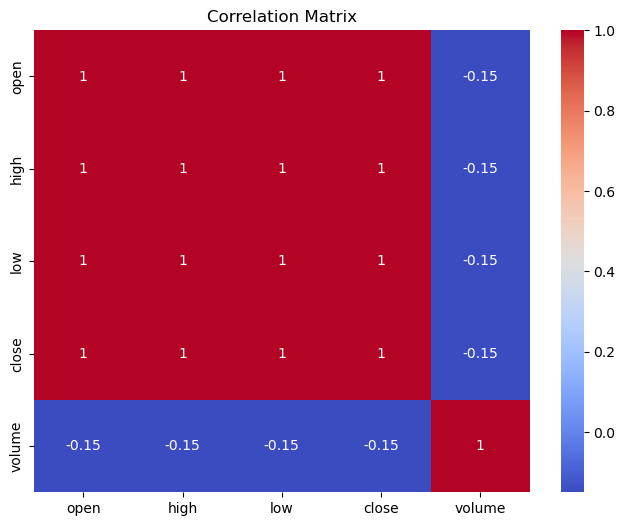

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(
corr,
annot=True,
cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

Closing price trend over time base on the Correlation Analysis

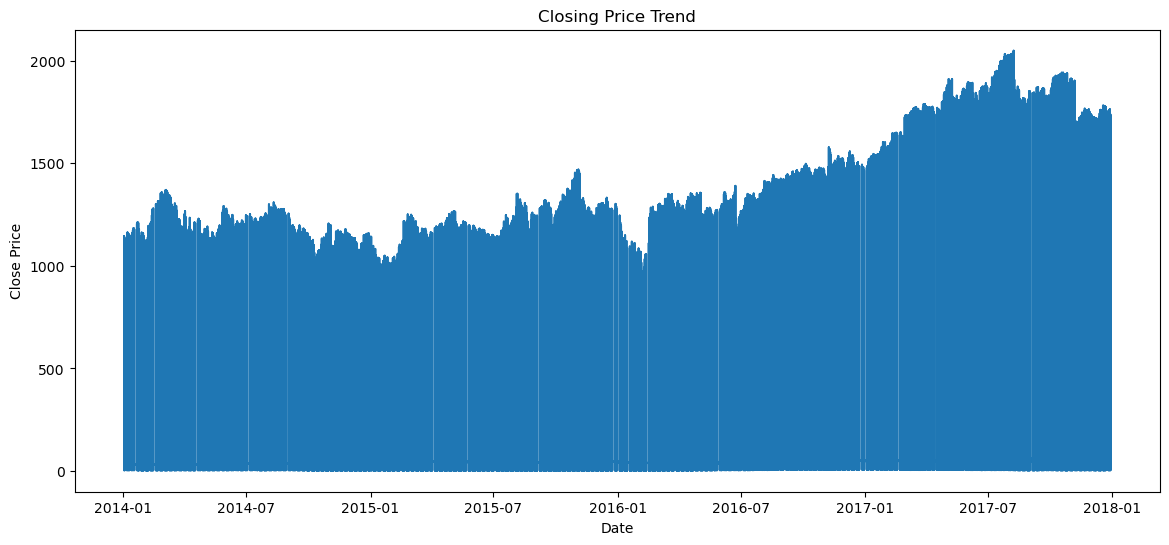

In [44]:
plt.figure(figsize=(14,6))
plt.plot(Stock_prices['date'], Stock_prices['close'])
plt.title('Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

Trading volume trend over time base on the Correlation Analysis

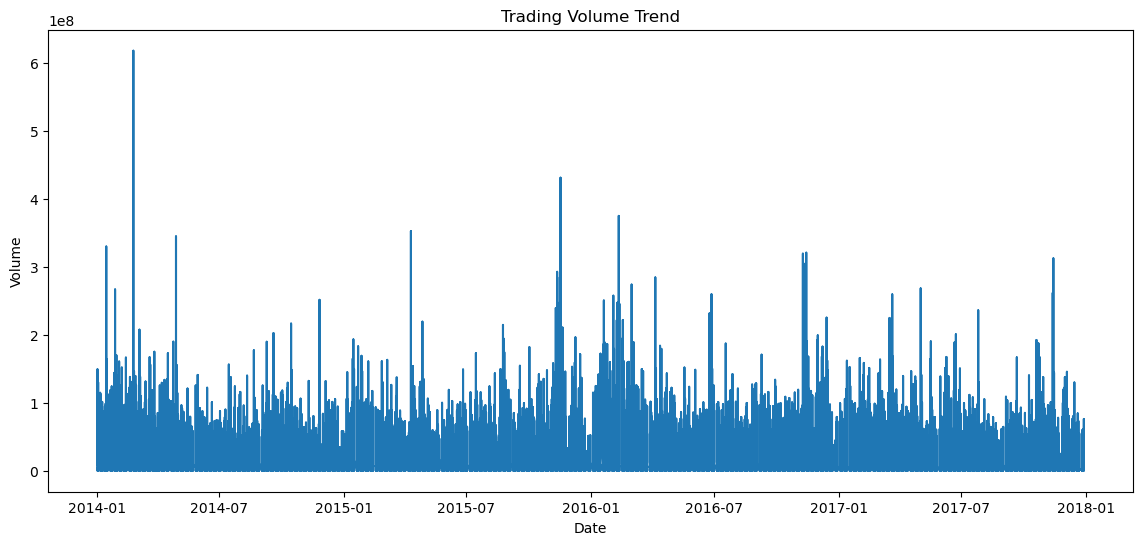

In [45]:
plt.figure(figsize=(14,6))
plt.plot(Stock_prices['date'], Stock_prices['volume'])
plt.title('Trading Volume Trend')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()